In [ ]:
import torch
import matplotlib.pyplot as plt
from pixel_arena.metrics import RunInfo

## Compare the best and worst mask of a model

In [ ]:
def plot_best_worst_mask(run: RunInfo, metric: torch.Tensor, metric_name: str, show_best_other_attempts: bool = False):
    image_ids_list = run.image_ids
    
    # Show the best
    m = metric.max(dim=1)
    max_scores = m.values
    max_value = max_scores.max()
    max_column_indices = m.indices
    # row for image, column for attemps
    max_row_index = max_scores.argmax()
    max_col_index = max_column_indices[max_row_index]
    best_image_id = image_ids_list[max_row_index.item()]
    best_attempt = max_col_index.item()

    image = run.get_original_image(best_image_id)
    mask_ref = run.get_mask_ref(image_id=best_image_id, return_image=True)
    mask_preds = run.get_mask_preds(image_id=best_image_id, return_image=True)
    best_mask_pred = mask_preds[best_attempt]

    if show_best_other_attempts:
        other_mask_preds = [
            mask_preds[i] for i in range(run.attempts) if i != best_attempt
        ]
        
        fig, axes = plt.subplots(2, 4, figsize=(15, 10))
        axes[0, 0].imshow(image)
        axes[0, 0].set_title("Original")
        axes[0, 0].axis("off")
        axes[0, 1].imshow(mask_ref)
        axes[0, 1].set_title("Reference Mask")
        axes[0, 1].axis("off")
        axes[0, 2].imshow(best_mask_pred)
        axes[0, 2].set_title(f"Best Predicted Mask - {metric_name}: {max_value:.4f}")
        axes[0, 2].axis("off")
        axes[0, 3].axis("off")
        
        for idx, mask in enumerate(other_mask_preds):
            axes[1, idx].imshow(mask)
            axes[1, idx].set_title(f"Other Mask Pred {idx + 1}")
            axes[1, idx].axis("off")
            
        for idx in range(len(other_mask_preds), 4):
            axes[1, idx].axis("off")
        
        plt.tight_layout()
        plt.show()
    else:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(image)
        axes[0].set_title("Original")
        axes[0].axis("off")
        axes[1].imshow(mask_ref)
        axes[1].set_title("Reference Mask")
        axes[1].axis("off")
        axes[2].imshow(best_mask_pred)
        axes[2].set_title(f"Best Predicted Mask - {metric_name}: {max_value:.4f}")
        axes[2].axis("off")
        plt.tight_layout()
        plt.show()

    # show the worst with other attempts

    m = metric.min(dim=1)
    min_scores = m.values
    min_value = min_scores.min()
    min_column_indices = m.indices
    # row for image, column for attemps
    min_row_index = min_scores.argmin()
    min_col_index = min_column_indices[min_row_index]
    worst_image_id = image_ids_list[min_row_index.item()]
    worst_attempt = min_col_index.item()

    image = run.get_original_image(worst_image_id)
    mask_ref = run.get_mask_ref(image_id=worst_image_id, return_image=True)
    mask_preds = run.get_mask_preds(image_id=worst_image_id, return_image=True)
    worst_mask_pred = mask_preds[worst_attempt]
    other_mask_preds = [
        mask_preds[i] for i in range(run.attempts) if i != worst_attempt
    ]

    fig, axes = plt.subplots(2, 4, figsize=(15, 10))

    # First row: original, reference, worst predicted
    axes[0, 0].imshow(image)
    axes[0, 0].set_title("Original")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(mask_ref)
    axes[0, 1].set_title("Reference Mask")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(worst_mask_pred)
    axes[0, 2].set_title(f"Worst Predicted Mask - {metric_name}: {min_value:.4f}")
    axes[0, 2].axis("off")

    axes[0, 3].axis("off")

    # Second row: the other 4 mask preds
    for idx, mask in enumerate(other_mask_preds):
        axes[1, idx].imshow(mask)
        axes[1, idx].set_title(f"Other Mask Pred {idx + 1}")
        axes[1, idx].axis("off")

    # Hide any unused axes in the second row (in case attemps < 3)
    for idx in range(len(other_mask_preds), 3):
        axes[1, idx].axis("off")

    plt.tight_layout()
    plt.show()

    return best_image_id, best_attempt, worst_image_id, worst_attempt

In [ ]:
from calculate_metrics import gemini_pro_run_celeb, gemini_pro_run_coco, gemini_run_coco

metric_name = "F1"
# run = gemini_pro_run_celeb
run = gemini_pro_run_coco
# run = gemini_run_coco

f1, iou, dice = run.load_metrics()
print(
    plot_best_worst_mask(
        run=run,
        metric=f1,
        metric_name=metric_name,
        show_best_other_attempts=True
    )
)

## Compare the best of Gemini Pro Image with Segface on CelebAMask-HQ

In [ ]:
from calculate_metrics import gemini_pro_run_celeb, segface_run_celeb

gmnp_f1, _, _ = gemini_pro_run_celeb.load_metrics()
segface_f1, _, _ = segface_run_celeb.load_metrics()

best_idx = segface_f1.flatten().argmax().item()
best_image_id = segface_run_celeb.image_ids[best_idx]

mask_segface = segface_run_celeb.get_mask_preds(
    image_id=best_image_id, return_image=True
)[0]
mask_gemini = gemini_pro_run_celeb.get_mask_preds(
    image_id=best_image_id, return_image=True
)[0]
original_image = gemini_pro_run_celeb.get_original_image(best_image_id)
reference_mask = gemini_pro_run_celeb.get_mask_ref(
    image_id=best_image_id, return_image=True
)

segface_f1_best = segface_f1[best_idx, 0].item()
gemini_pro_f1 = gmnp_f1[best_idx, 0].item()

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0, 0].imshow(original_image)
axs[0, 0].set_title("Original Image")
axs[0, 0].axis("off")

axs[0, 1].imshow(reference_mask)
axs[0, 1].set_title("Reference Mask")
axs[0, 1].axis("off")

axs[1, 0].imshow(mask_segface)
axs[1, 0].set_title(f"segface: f1={segface_f1_best:.4f}")
axs[1, 0].axis("off")

axs[1, 1].imshow(mask_gemini)
axs[1, 1].set_title(f"gemini-3-pro-image-preview: f1={gemini_pro_f1:.4f}")
axs[1, 1].axis("off")

plt.tight_layout()
plt.show()

## Compare results of different models

In [4]:
from calculate_metrics import *
import matplotlib.pyplot as plt

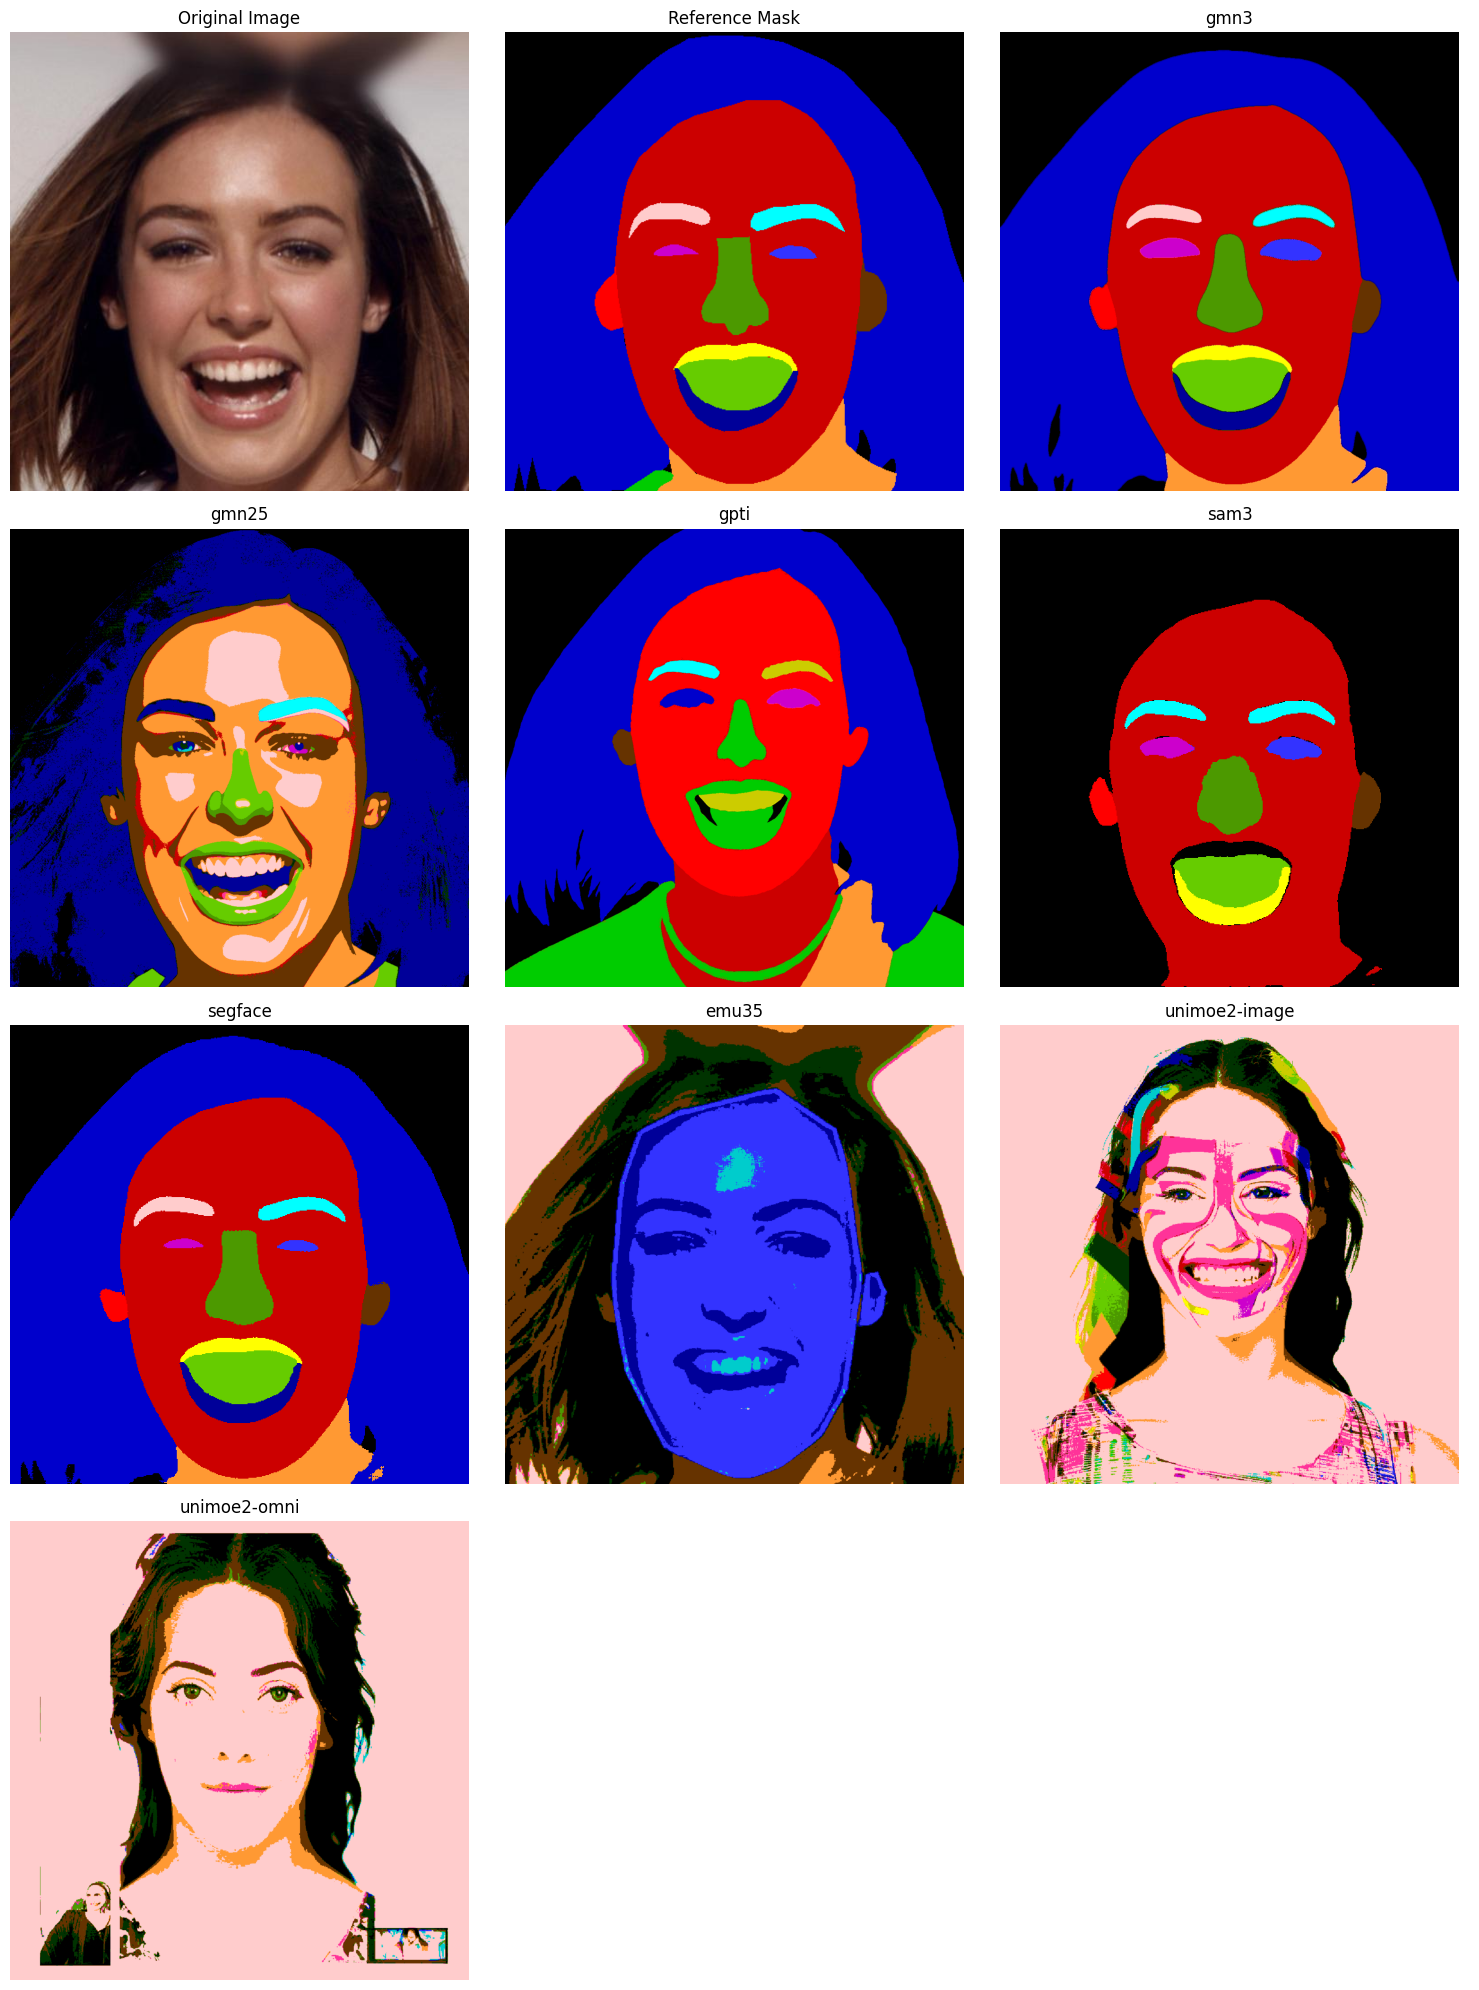

In [8]:
runs = [
    gemini_pro_run_celeb,
    gemini_run_celeb,
    gpt_run_celeb,
    sam3_run_celeb,
    segface_run_celeb,
    emu35_run_celeb,
    uni_moe_2_image_run_celeb,
    uni_moe_2_omni_run_celeb,
]

image_id = "0a82f5055de94783bb8e91ed6dfbd547"
original_image = runs[0].get_original_image(image_id)
reference_mask = runs[0].get_mask_ref(image_id=image_id, return_image=True)
attempt_idx = 0

fig, axes = plt.subplots(4, 3, figsize=(15, 20))
axes = axes.flatten()

axes[0].imshow(original_image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(reference_mask)
axes[1].set_title("Reference Mask")
axes[1].axis("off")

for i, run in enumerate(runs):
    ax = axes[i + 2]
    mask_preds = run.get_mask_preds(image_id=image_id, return_image=True)
    mask = mask_preds[attempt_idx]
    ax.imshow(mask)
    ax.set_title(run.model_code_name)
    ax.axis("off")

for i in range(len(runs) + 2, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()